In [1]:
using Pkg
Pkg.activate(@__DIR__)

include(joinpath(@__DIR__, "load_results.jl"))


  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark`


build_metric_matrix

In [2]:
using BenchmarkProfiles
using Plots
using PGFPlotsX
using Printf
using LinearAlgebra
using Statistics

In [3]:
pgfplotsx()
# gr()

Plots.PGFPlotsXBackend()

In [4]:
# ---------------------------------------------------------------------------
# I/O directories
# ---------------------------------------------------------------------------
const RESULTS_DIR = joinpath(@__DIR__, "results")
const FIGURES_DIR = joinpath(@__DIR__, "figures")
const TABLES_DIR  = joinpath(@__DIR__, "tables")
mkpath(FIGURES_DIR)
mkpath(TABLES_DIR)

"c:\\Users\\jerem\\OneDrive\\Desktop\\GitHub\\TrustRegionRadius.jl\\benchmark\\tables"

In [5]:
# ---------------------------------------------------------------------------
# Colour / style constants (shared across all experiments)
# ---------------------------------------------------------------------------
const RULE_COLORS = Dict(
    "R1" => colorant"#3266AD",
    "R2" => colorant"#1D9E75",
    "R3" => colorant"#D85A30",
    "R4" => colorant"#9933AA",
)
const RULE_STYLES = Dict(
    "R1" => :solid,
    "R2" => :solid,
    "R3" => :dash,
    "R4" => :dot,
)


Dict{String, Symbol} with 4 entries:
  "R4" => :dot
  "R3" => :dash
  "R1" => :solid
  "R2" => :solid

In [6]:
# ---------------------------------------------------------------------------
# Load benchmark data
# ---------------------------------------------------------------------------
@info "Loading results…"
results, prob_names, rule_names = load_all_results(RESULTS_DIR)

# Work only on problems where every mechanism has a result (any status)
common_probs = filter(prob_names) do p
    all(r -> haskey(results[p], r), rule_names)
end
@info "Problems with results for all mechanisms: $(length(common_probs))"


[ Info: Loading results…
[ Info: Loaded results: 75 problems × 4 mechanisms
[ Info: Problems with results for all mechanisms: 74


In [7]:
# ---------------------------------------------------------------------------
# Build metric matrices  (rows = problems, cols = solvers)
# Inf → failure / max_iter
# ---------------------------------------------------------------------------
function metric_matrix(metric_fn)
    m = length(common_probs)
    s = length(rule_names)
    M = fill(Inf, m, s)
    for (i, p) in enumerate(common_probs), (j, r) in enumerate(rule_names)
        entry = results[p][r]
        if entry.status == :solved
            M[i, j] = metric_fn(entry)
        end
    end
    return M
end

T_iter   = metric_matrix(e -> Float64(e.iterations))
T_fevals = metric_matrix(e -> Float64(e.f_evals))


74×4 Matrix{Float64}:
  9.0   17.0    9.0    9.0
 15.0   18.0   12.0   19.0
  9.0    8.0    8.0   12.0
 33.0   48.0   31.0   55.0
 10.0    8.0    7.0    8.0
  4.0    4.0    4.0    4.0
 52.0  115.0   30.0    5.0
  6.0    6.0    6.0    9.0
 28.0   41.0   31.0   41.0
 10.0   10.0   10.0   11.0
 43.0   59.0   48.0   49.0
 13.0   17.0   15.0   24.0
 14.0   26.0   14.0   13.0
  ⋮                  
 10.0   10.0   10.0   10.0
  6.0    6.0    6.0    3.0
  6.0    6.0    6.0    3.0
 92.0  132.0  103.0  144.0
 13.0   13.0   13.0   14.0
 13.0   13.0   13.0   14.0
 79.0  101.0  455.0   88.0
 16.0   18.0   16.0   16.0
 16.0   18.0   16.0   16.0
 29.0   31.0   28.0   30.0
 29.0   31.0   28.0   30.0
  3.0    3.0    3.0    2.0

[ Info: Saved exp1_perf_profile_iter.pdf
[ Info: Saved exp1_perf_profile_fevals.pdf


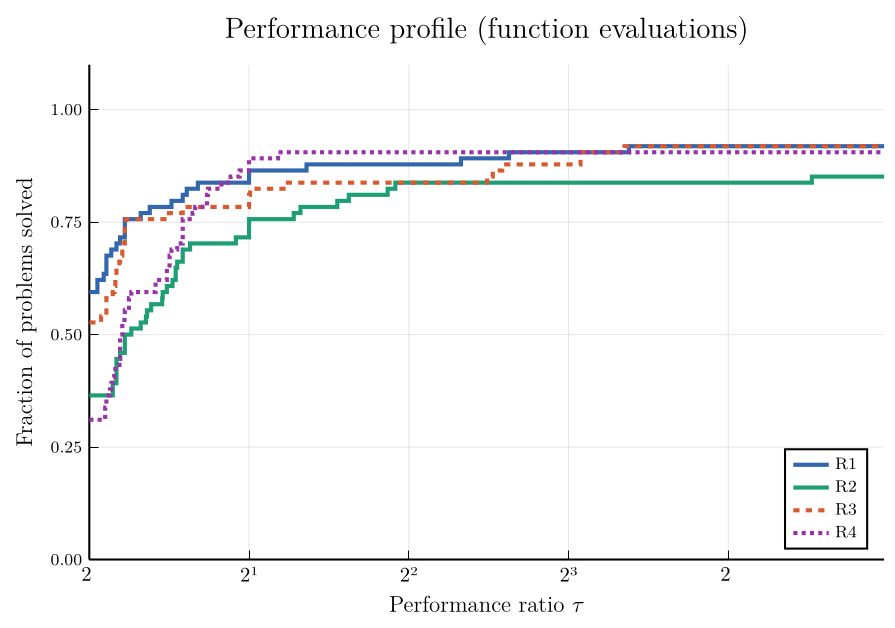

In [8]:
# ---------------------------------------------------------------------------
# Performance profiles
# ---------------------------------------------------------------------------
function make_perf_profile(T, metric_label, fname)
    p = performance_profile(
        PlotsBackend(), 
        T, rule_names;
        title    = "Performance profile ($metric_label)",
        xlabel   = "Performance ratio τ",
        ylabel   = "Fraction of problems solved",
        logscale = true,
        legend   = :bottomright,
    )
    for (i, rname) in enumerate(rule_names)
        p.series_list[i][:linecolor] = RULE_COLORS[rname]
        p.series_list[i][:linestyle] = RULE_STYLES[rname]
        p.series_list[i][:linewidth] = 2
    end
    savefig(p, joinpath(FIGURES_DIR, fname))
    @info "Saved $fname"
    return p
end

p_iter   = make_perf_profile(T_iter,   "iterations",         "exp1_perf_profile_iter.pdf")
p_fevals = make_perf_profile(T_fevals, "function evaluations", "exp1_perf_profile_fevals.pdf")



In [9]:
# ---------------------------------------------------------------------------
# Data profile
# ---------------------------------------------------------------------------
# H[k, p, s] = objective value after the k-th function evaluation for
# problem p, solver s.  We use obj_trajectory (one entry per iteration,
# starting from k=0) as a proxy for f-eval count.
# N[p] = n(p) + 1  — simplex-gradient scaling (Moré–Wild convention).
# Unsolved / missing entries remain Inf, which data_profile treats as failure.

np_c = length(common_probs)
ns_c = length(rule_names)

# Maximum trajectory length across all (problem, solver) pairs
max_K = maximum(
    length(results[p][r].obj_trajectory)
    for p in common_probs for r in rule_names
    if haskey(results[p], r) && !isempty(results[p][r].obj_trajectory);
    init = 2,
)

H = fill(Inf, max_K, np_c, ns_c)
for (i, p) in enumerate(common_probs), (j, r) in enumerate(rule_names)
    haskey(results[p], r) || continue
    entry = results[p][r]
    traj  = entry.obj_trajectory
    isempty(traj) && continue
    nt = length(traj)
    for k in 1:min(nt, max_K)
        H[k, i, j] = traj[k]
    end
    # Pad with final value for solved problems (already at optimum)
    if entry.status == :solved && nt < max_K
        H[nt+1:max_K, i, j] .= traj[end]
    end
end

# N[p] = n + 1 (simplex-gradient scaling); fall back to 2 if n unknown
N_scale = Float64[max(results[p][rule_names[1]].n + 1, 2) for p in common_probs]

p_data = data_profile(
    PlotsBackend(),
    H,
    N_scale,
    AbstractString[r for r in rule_names];
    τ          = 1.0e-3,
    operations = "function evaluations",
    title      = "Data profile (τ = 1e-3)",
)
savefig(p_data, joinpath(FIGURES_DIR, "exp1_data_profile.pdf"))
@info "Saved exp1_data_profile.pdf"



[ Info: Saved exp1_data_profile.pdf


In [10]:
# ---------------------------------------------------------------------------
# Success-rate table
# ---------------------------------------------------------------------------
println("\n" * "="^70)
println("EXP 1 — Success rates")
println("="^70)

header  = @sprintf("%-6s  %8s  %8s  %8s  %8s  %7s",
                   "Rule", "Solved", "MaxIter", "Failed", "Total", "Rate%")
divider = "-"^55
println(header)
println(divider)

latex_rows = String[]
for rname in rule_names
    ns  = count(p -> haskey(results[p], rname) && results[p][rname].status == :solved,   common_probs)
    nm  = count(p -> haskey(results[p], rname) && results[p][rname].status == :max_iter, common_probs)
    nf  = count(p -> haskey(results[p], rname) && results[p][rname].status ∉ (:solved, :max_iter), common_probs)
    tot = ns + nm + nf
    rate = tot > 0 ? 100 * ns / tot : 0.0

    println(@sprintf("%-6s  %8d  %8d  %8d  %8d  %7.1f", rname, ns, nm, nf, tot, rate))

    # LaTeX row
    push!(latex_rows,
          @sprintf("%s & %d & %d & %d & %d & %.1f\\%%  \\\\",
                   rname, ns, nm, nf, tot, rate))
end
println("="^70)

# Write LaTeX table
table_path = joinpath(TABLES_DIR, "exp1_success_rate.txt")
open(table_path, "w") do io
    println(io, "% Exp 1 — Success rate table (auto-generated by exp1_global.jl)")
    println(io, "% Columns: Rule | Solved | MaxIter | Failed | Total | Rate%")
    println(io, "\\begin{tabular}{lrrrrr}")
    println(io, "\\toprule")
    println(io, "Rule & Solved & Max-iter & Failed & Total & Rate (\\%) \\\\")
    println(io, "\\midrule")
    for row in latex_rows
        println(io, row)
    end
    println(io, "\\bottomrule")
    println(io, "\\end{tabular}")
end
@info "Saved tables/exp1_success_rate.txt"



EXP 1 — Success rates
Rule      Solved   MaxIter    Failed     Total    Rate%
-------------------------------------------------------
R1            68         6         0        74     91.9
R2            63        11         0        74     85.1
R3            68         6         0        74     91.9
R4            67         7         0        74     90.5


[ Info: Saved tables/exp1_success_rate.txt


In [11]:
# ---------------------------------------------------------------------------
# Median-iteration / median-fevals summary
# ---------------------------------------------------------------------------
println("\nMedian metrics (solved problems only):")
println(@sprintf("%-6s  %10s  %10s", "Rule", "Med-iter", "Med-fevals"))
println("-"^32)
for (j, rname) in enumerate(rule_names)
    solved_iter   = T_iter[isfinite.(T_iter[:, j]),   j]
    solved_fevals = T_fevals[isfinite.(T_fevals[:, j]), j]
    med_i = isempty(solved_iter)   ? NaN : Statistics.median(solved_iter)
    med_f = isempty(solved_fevals) ? NaN : Statistics.median(solved_fevals)
    println(@sprintf("%-6s  %10.1f  %10.1f", rname, med_i, med_f))
end



Median metrics (solved problems only):
Rule      Med-iter  Med-fevals
--------------------------------
R1            12.0        13.0
R2            12.0        13.0
R3            12.0        13.0
R4            13.0        14.0
